In [1]:
import sys
from datetime import datetime, timedelta

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as tickerdahu35
from scipy import stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from matplotlib.legend_handler import HandlerTuple
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import dask
#import rasterio
import os 
os.listdir("/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work")

import matplotlib.colors as mcolors # Import les palettes de couleurs
import cartopy.crs as ccrs # Permet d'utiliser des projections de cartes
import cartopy.feature as cfeature # Permet d'ajouter d'autres éléments à la carte
import matplotlib.patches as patches # Permet de tracer des rectangles dans mon cas

In [2]:
k = 15

iyear=1960
fyear=2025

ice_level = 30 # Seuil à partir duquel on considère qu'on observe de la glace

In [3]:
GridPath='/home/amoryc/'
Domain_grM='NST.2000.01.01.00.GRq.nc'

ds_grM= xr.open_dataset(GridPath+Domain_grM)

ds_lon = ds_grM.LON[k:-k, k:-k] # Longitude
ds_lat = ds_grM.LAT[k:-k, k:-k] # Latitude
ds_SH  = ds_grM.SH[k:-k, k:-k] # Topographie en m
ds_ICE = ds_grM.ICE[k:-k, k:-k] # Pourcentage de glace par maille

# Coordonnées exactes du Peak Mera
merap_lat = 27.70984
merap_lon = 86.868662

# Coordonnées Everest
everest_lat = 27.9879017
everest_lon = 86.9253141

# Loading MAR data 

In [4]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/monthly/' # On regarde les données monthly car même chose que daily en moins long

SMB = xr.open_mfdataset(DataPath+variable+f'_monsum_MARv3.14_ER5_spin2_GRq_*.nc',combine="by_coords")['SMB'] # * Permet de compiler chacune des années grâce à mfdataset. ['SMB'] transforme le dataset en data_array
SMB = SMB.isel(SECTOR=0)
SMB = SMB.rename({'TIME': 'time'})
SMB = SMB[:,k:-k,k:-k].sel(time=slice(str(iyear),str(fyear))) # restreint au bord le domaine et sélectionne les années voulues

In [5]:
########## Traitement de la variable SMB #########
ds = SMB.sel(time=slice(f"{iyear-1}-12", f"{fyear}-12")) # Selectionne la variable sur la période

annual_values = ds.groupby("time.year").sum(dim='time', skipna=True) # Regroupe par années et somme les données monthly
annual_mean = annual_values.mean(dim='year')/1000 # Moyenne climatologique pour toute la période et conversion de mm en m.w.e

annual_mean_masked = annual_mean.where(annual_mean != 0) # Permet de mettre en blanc les valeurs strictement égales à 0

In [6]:
print(ds.shape) # 12(mois)*65(années) , y , x
print(annual_values.shape) # 65(années) , y , x
print(annual_mean.shape) #y , x

(780, 52, 86)
(65, 52, 86)
(52, 86)


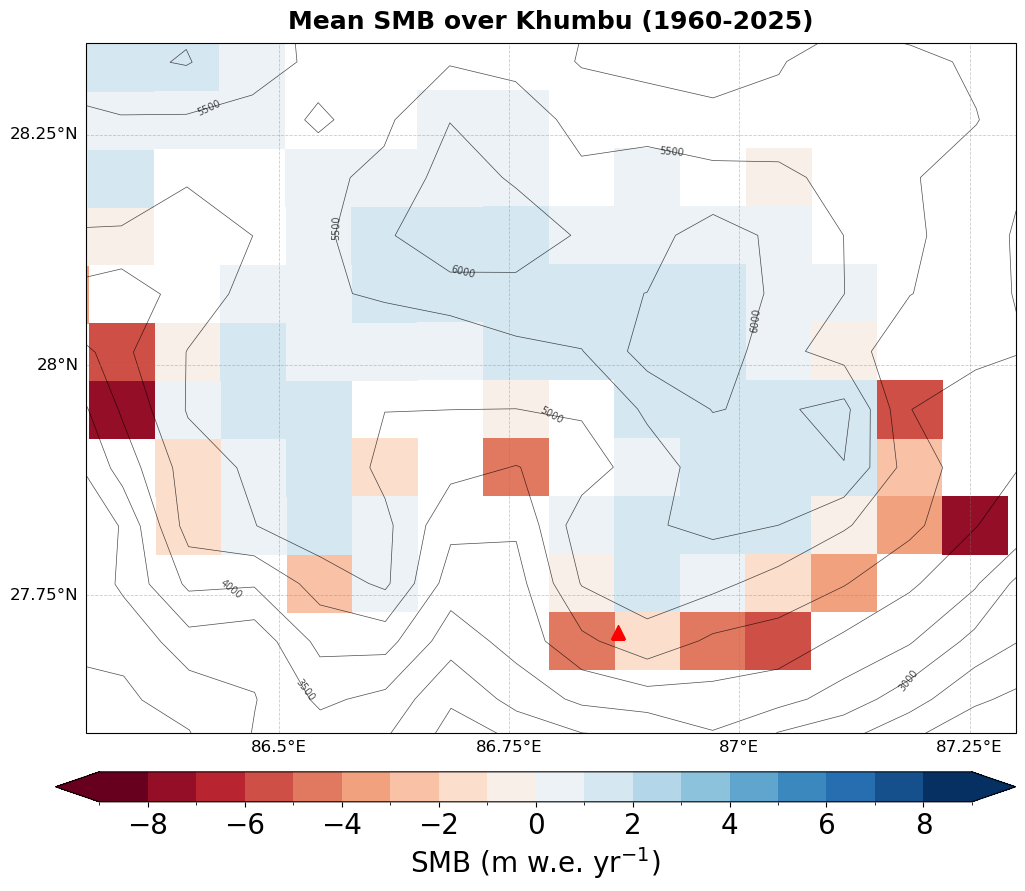

In [7]:
############### Mean SMB Map (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré


############# Color map ###############
vmin = -9
vmax = 9
step = 1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")More
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=10, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# SMB moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_mean_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"Mean SMB over Khumbu ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("SMB (m w.e. yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Mean_SMB_all.png")

In [8]:
ds_ex = SMB.sel(time=slice("2023-01", "2024-12"))

ex_values = ds.groupby("time.year").sum(dim='time', skipna=True)

ex_field = ex_values.sel(year=2024) / 1000

ex_mean_masked = ex_field.where(ex_field != 0)

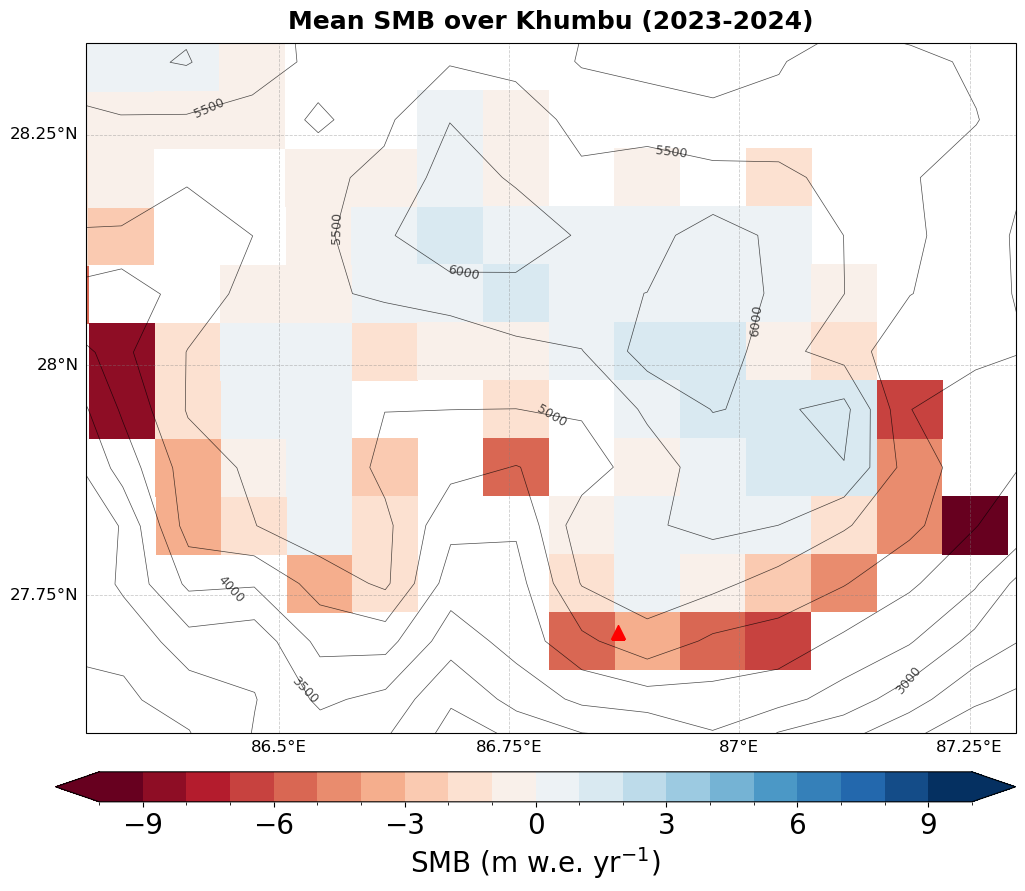

In [9]:
############### Mean SMB Map (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

############# Color map ###############
vmin = -10
vmax = 10
step = 1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")More
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=9, fmt='%d', manual=manual_locations)

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=10, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# SMB moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, ex_mean_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), shading="auto")

########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"Mean SMB over Khumbu ({2023}-{2024})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("SMB (m w.e. yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Mean_SMB_2024.png")


3.7256467
-11.487059
[-11.487059   -10.321644    -8.610077    -8.549956    -8.232933
  -7.809314    -7.7291746   -7.6125374   -7.0025573   -6.8677583
  -6.667033    -6.453321    -5.9346848   -5.7412457   -5.494251
  -5.436353    -5.420656    -5.4054837   -5.375704    -5.2900786
  -5.059866    -5.0119033   -4.991492    -4.844923    -4.72654
  -4.6599836   -4.629023    -4.567755    -4.5045      -4.4903426
  -4.4598465   -4.4254746   -4.4193573   -4.407608    -4.174761
  -4.0909615   -4.033228    -4.0314426   -3.9808602   -3.966876
  -3.8586693   -3.8463879   -3.8036947   -3.7449875   -3.6614182
  -3.6374464   -3.58695     -3.5062726   -3.5022495   -3.467544
  -3.448449    -3.4312024   -3.3999386   -3.3616076   -3.2168562
  -3.1474826   -3.0748475   -3.0602045   -3.0507164   -3.0144928
  -2.9369204   -2.8417366   -2.7594645   -2.690864    -2.6555648
  -2.6486685   -2.6388705   -2.598364    -2.5486367   -2.5135937
  -2.3986163   -2.3732436   -2.3668935   -2.3606083   -2.266471
  -2.1746356

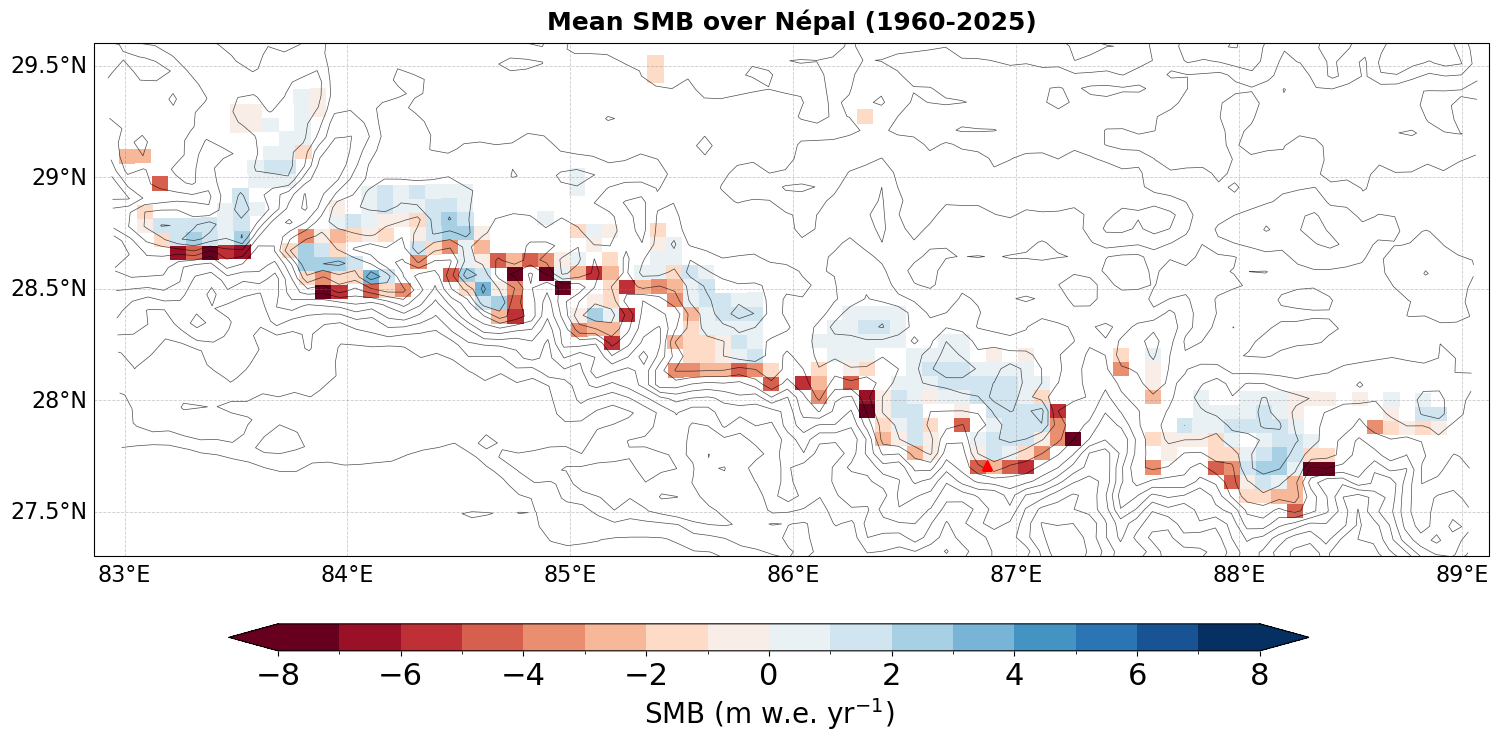

In [50]:
############### Mean SMB Map (1960-2025) #######################

fig, ax = plt.subplots(figsize=(18,18),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré


############# Color map ###############
vmin = -8
vmax = 8
step = 1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

######## Countour glaciers #########
#ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=7, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# SMB moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_mean_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 16}
gl.ylabel_style = {"size": 16}
gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
gl.ylocator = mticker.MaxNLocator(5)

lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, 27.3, 29.6],crs=ccrs.PlateCarree())


ax.set_title(f"Mean SMB over Népal ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.2, 0.3, 0.6, 0.015])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("SMB (m w.e. yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=22)

plt.savefig("Mean_SMB_all.png", dpi=400, bbox_inches="tight")

print(annual_mean_masked.max().values)
print(annual_mean_masked.min().values)

values = annual_mean_masked.values.flatten()
values = values[~np.isnan(values)]  # retire les NaN

values_sorted = np.sort(values)

print(values_sorted)

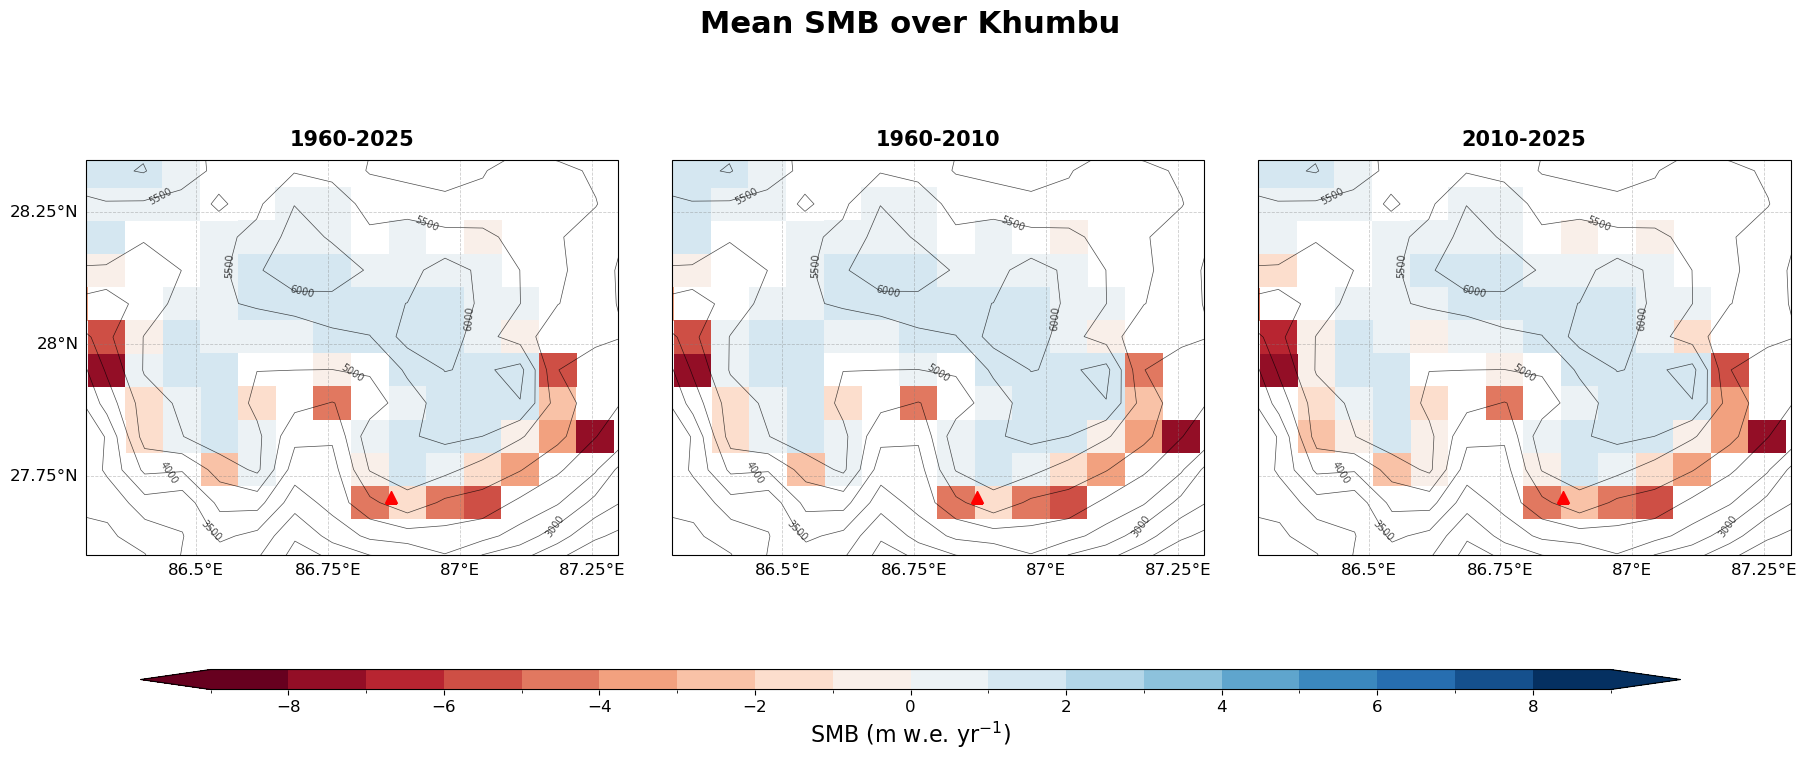

In [11]:
############### Subplot Mean SMB Map #######################

fig, axes = plt.subplots(1, 3, figsize=(22, 8), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
periods = [(1960, 2025), (1960, 2010), (2010, 2025)]

########## Color map ###############
vmin = -9
vmax = 9
step = 1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


#############################################################
############### Boucles pour les périodes ###################
for ax, (start, end) in zip(axes, periods):
    
    ds = SMB.sel(time=slice(f"{start}-01", f"{end}-12")) # Selection de période

    annual_values = ds.groupby("time.year").sum(dim='time', skipna=True)
    annual_mean = annual_values.mean(dim='year') / 1000
    annual_mean_masked = annual_mean.where(annual_mean != 0)


    
    ############### Plot ###############
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

    ########### Topography lines values #############
    manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
    ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# SMB moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, annual_mean_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

    

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}
    gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
    gl.ylocator = mticker.MaxNLocator(3)

    ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
    
    ax.set_title(f"{start}-{end}",fontsize=15,weight="bold", pad=10)

#######################################################################
#######################################################################
    


fig.suptitle("Mean SMB over Khumbu", fontsize=22, weight="bold", y=0.93) 

cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.025])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("SMB (m w.e. yr$^{-1}$)", fontsize=16)

cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(wspace=0.1) # Espacement subplots

plt.savefig("Mean_SMB_sub.png")

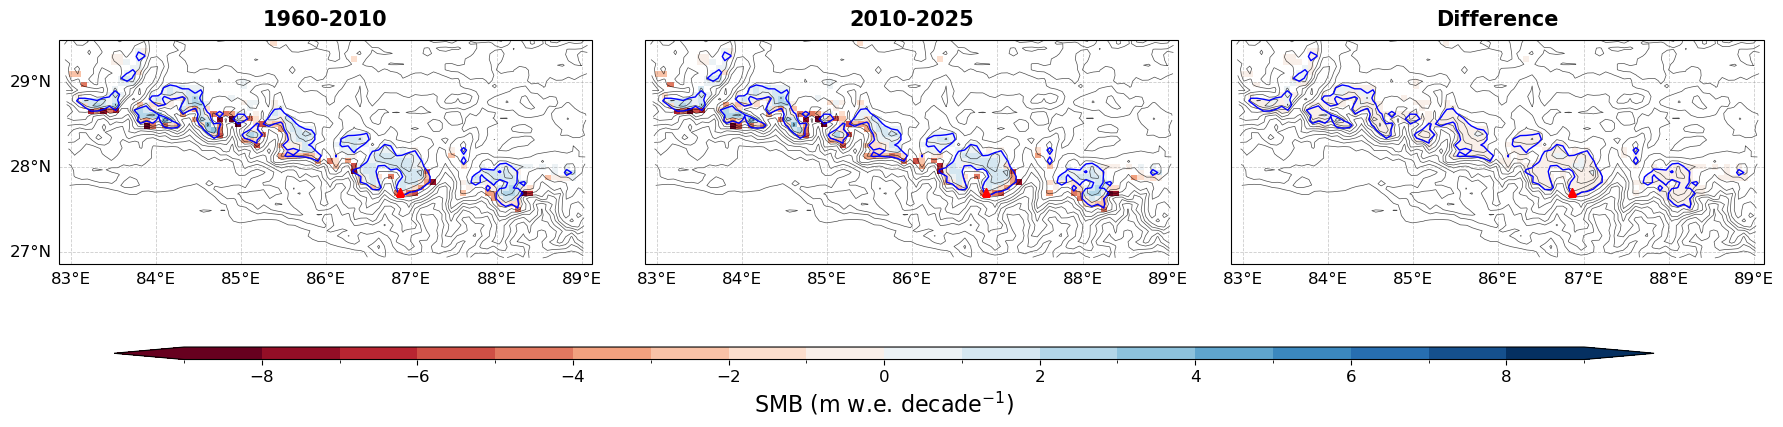

In [12]:
############### Subplot Mean SMB Map #######################

fig, axes = plt.subplots(1, 3, figsize=(22, 5), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
period1 = (1960, 2010)
period2 = (2010, 2025)

########## Fonction pour calculer le SMB moyen ##########
def compute_mean_smb(start, end):

    ds = SMB.sel(time=slice(f"{start}-01", f"{end}-12"))

    annual_values = ds.groupby("time.year").sum(dim="time", skipna=True)

    annual_mean = annual_values.mean(dim="year") / 1000

    return annual_mean

smb_1 = compute_mean_smb(*period1)
smb_2 = compute_mean_smb(*period2)
smb_diff = smb_2 - smb_1

maps = [(smb_1, f"{period1[0]}-{period1[1]}"), (smb_2, f"{period2[0]}-{period2[1]}"), (smb_diff, "Difference")]

########## Color map ###############
vmin = -9
vmax = 9
step = 1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


#############################################################
############### Boucles pour les périodes ###################
for ax, (data, title) in zip(axes, maps):

    data_masked = data.where(data != 0)    
    
    ############### Plot ###############
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

    ######## Countour glaciers #########
    ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=6, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# SMB moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, data_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}
    gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
    gl.ylocator = mticker.MaxNLocator(3)

    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())
    
    ax.set_title(title,fontsize=15,weight="bold", pad=10)

#######################################################################
#######################################################################ax.set_extent

cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.025])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("SMB (m w.e. decade$^{-1}$)", fontsize=16)

cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(wspace=0.1) # Espacement subplots


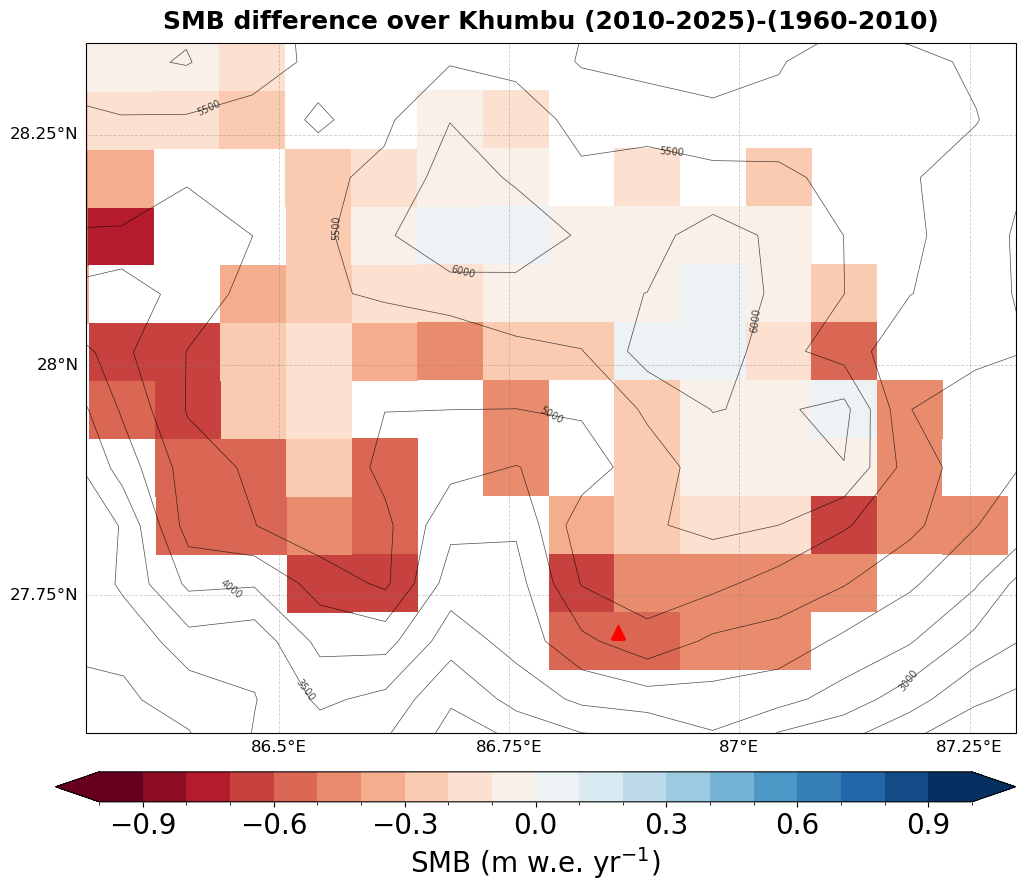

In [13]:
############### Mean SMB Map (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

data_masked = smb_diff.where(smb_diff != 0) # Permet de mettre en blanc les valeurs strictement égales à 0

############# Color map ###############
vmin = -1
vmax = 1
step = 0.1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=10, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# SMB moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, data_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"SMB difference over Khumbu ({2010}-{fyear})-({iyear}-{2010})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("SMB (m w.e. yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Mean_SMB_diff.png")

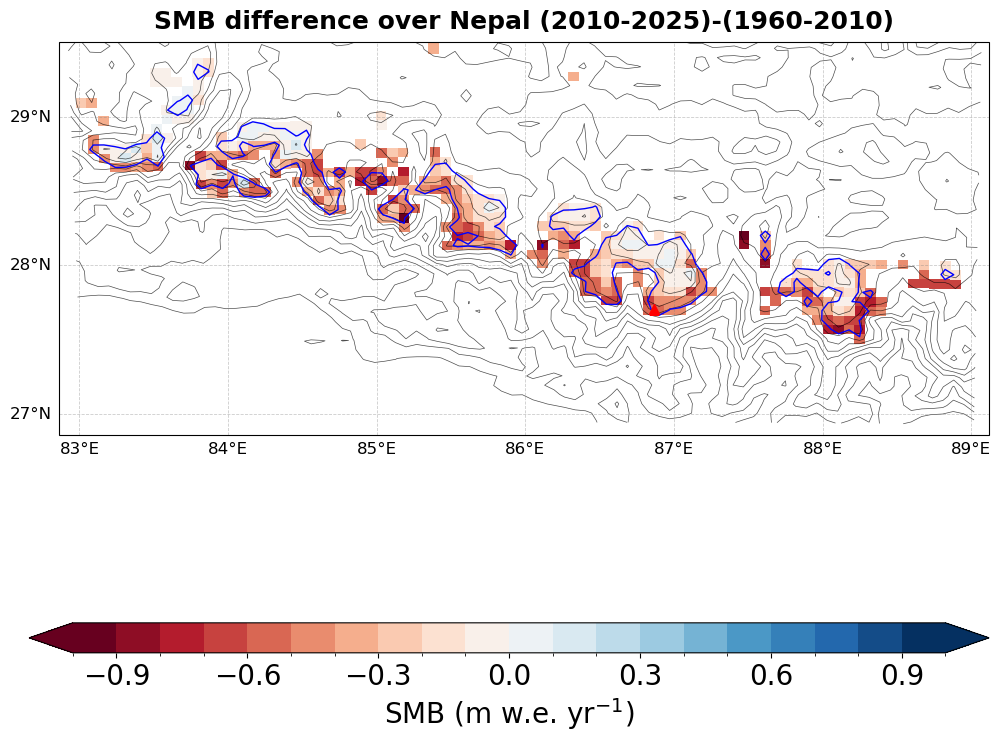

In [14]:
############### Mean SMB Map (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

data_masked = smb_diff.where(smb_diff != 0) # Permet de mettre en blanc les valeurs strictement égales à 0

############# Color map ###############
vmin = -1
vmax = 1
step = 0.1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=7, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# SMB moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, data_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
gl.ylocator = mticker.MaxNLocator(3)

lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())

ax.set_title(f"SMB difference over Nepal ({2010}-{fyear})-({iyear}-{2010})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("SMB (m w.e. yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Mean_SMB_diff.png")

# Trend

In [15]:
def trend_vect(x,y,dim): # Fonction donné par Jérémy pour calcul de trend
    '''
    Compute the spatial trend vectorized, instead of grid by grid.
    ex:
    par=trend_vect(vals.time,vals,'time')

    Source:https://stackoverflow.com/questions/52094320/with-xarray-how-to-parallelize-1d-operations-on-a-multidimensional-dataset
    https://github.com/mickaellalande/MC-Toolkit/blob/master/conda_environment_xarray_xesmf_proplot/xarray/advanced-analysis.ipynb
    
    You can also use a loop on lon/lat but way longer!-> spatial_regression()
    '''
    #print('trend-0','intercept-1','rvalue-2','pvalue-3','stderr-4')
    return xr.apply_ufunc(
        stats.linregress, x, y,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[[], [], [], [], []],
        vectorize=True
        )

In [16]:
ds = SMB.sel(time=slice(f"{iyear-1}-12", f"{fyear}-12"))

annual_values = ds.groupby("time.year").sum(dim='time', skipna=True)

annual_values = annual_values.load()
print(annual_values.dims)

slope, intercept, rvalue, pvalue, stderr = trend_vect(annual_values.year, annual_values, dim="year")
annual_trend = slope * 10 / 1000

annual_trend_masked = annual_trend.where(annual_trend != 0) # Permet de mettre en blanc les valeurs strictement égales à 0

('year', 'Y', 'X')


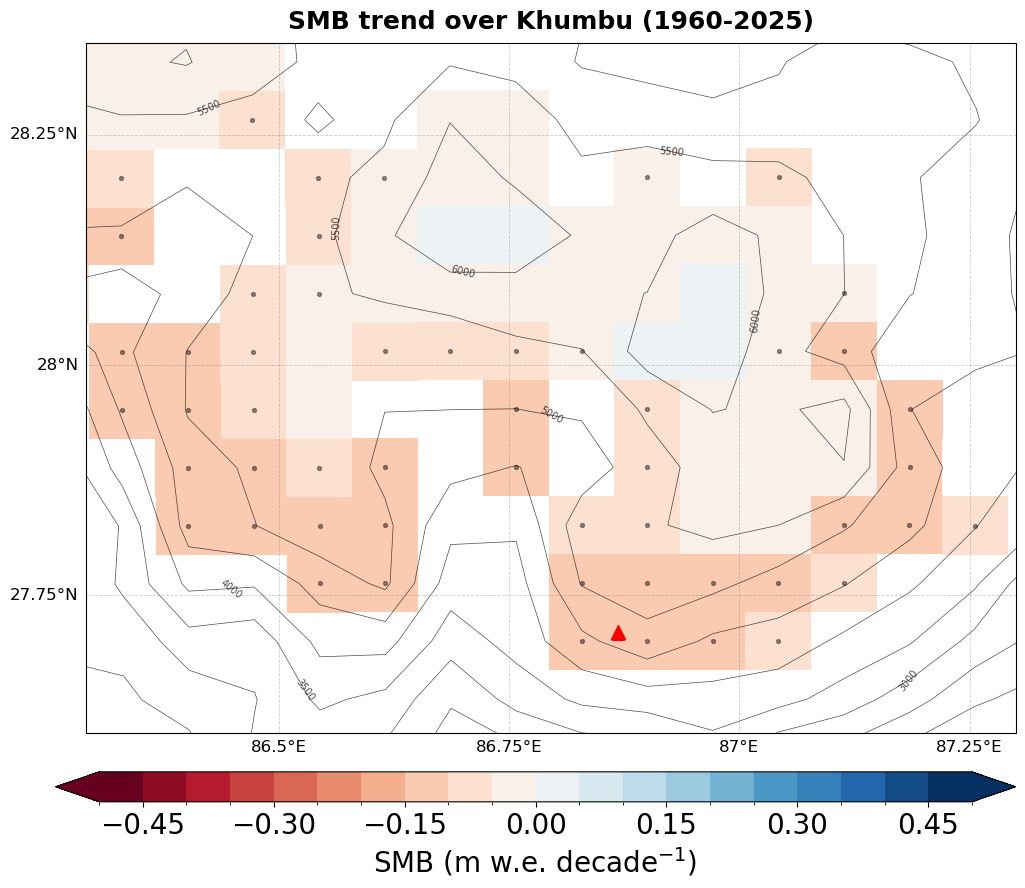

In [17]:
############### SMB trend Map (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré


############# Color map ###############
vmin = -0.5
vmax = 0.5
step = 0.05
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=10, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# SMB moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_trend_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

lon2d = ds_lon.values
lat2d = ds_lat.values

sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
step = 1
mask = sig.values

ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.4) # Affiche les valeurs significatives des tendances


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"SMB trend over Khumbu ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("SMB (m w.e. decade$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Trend_SMB_all.png")

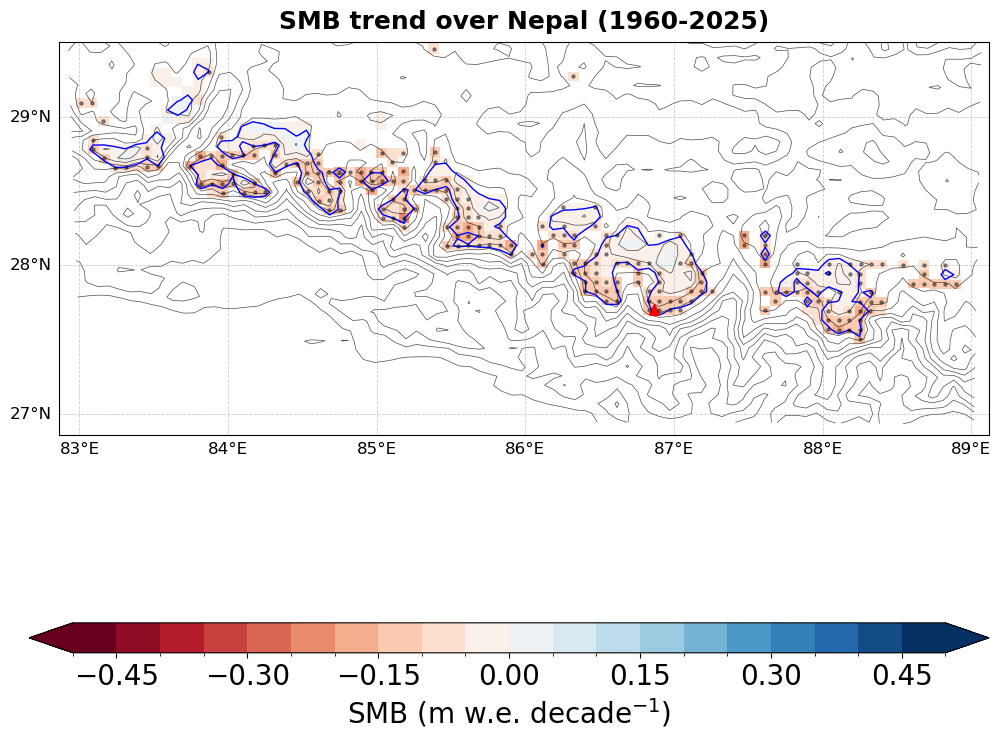

In [18]:
############### SMB trend Map (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré


############# Color map ###############
vmin = -0.5
vmax = 0.5
step = 0.05
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=7, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# SMB moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_trend_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

lon2d = ds_lon.values
lat2d = ds_lat.values

sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
step = 1
mask = sig.values

ax.scatter(lon2d[mask], lat2d[mask], color='black', s=5, transform=ccrs.PlateCarree(), zorder=5, alpha=0.4) # Affiche les valeurs significatives des tendances


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
gl.ylocator = mticker.MaxNLocator(3)

lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())

ax.set_title(f"SMB trend over Nepal ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("SMB (m w.e. decade$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Trend_SMB_all.png")

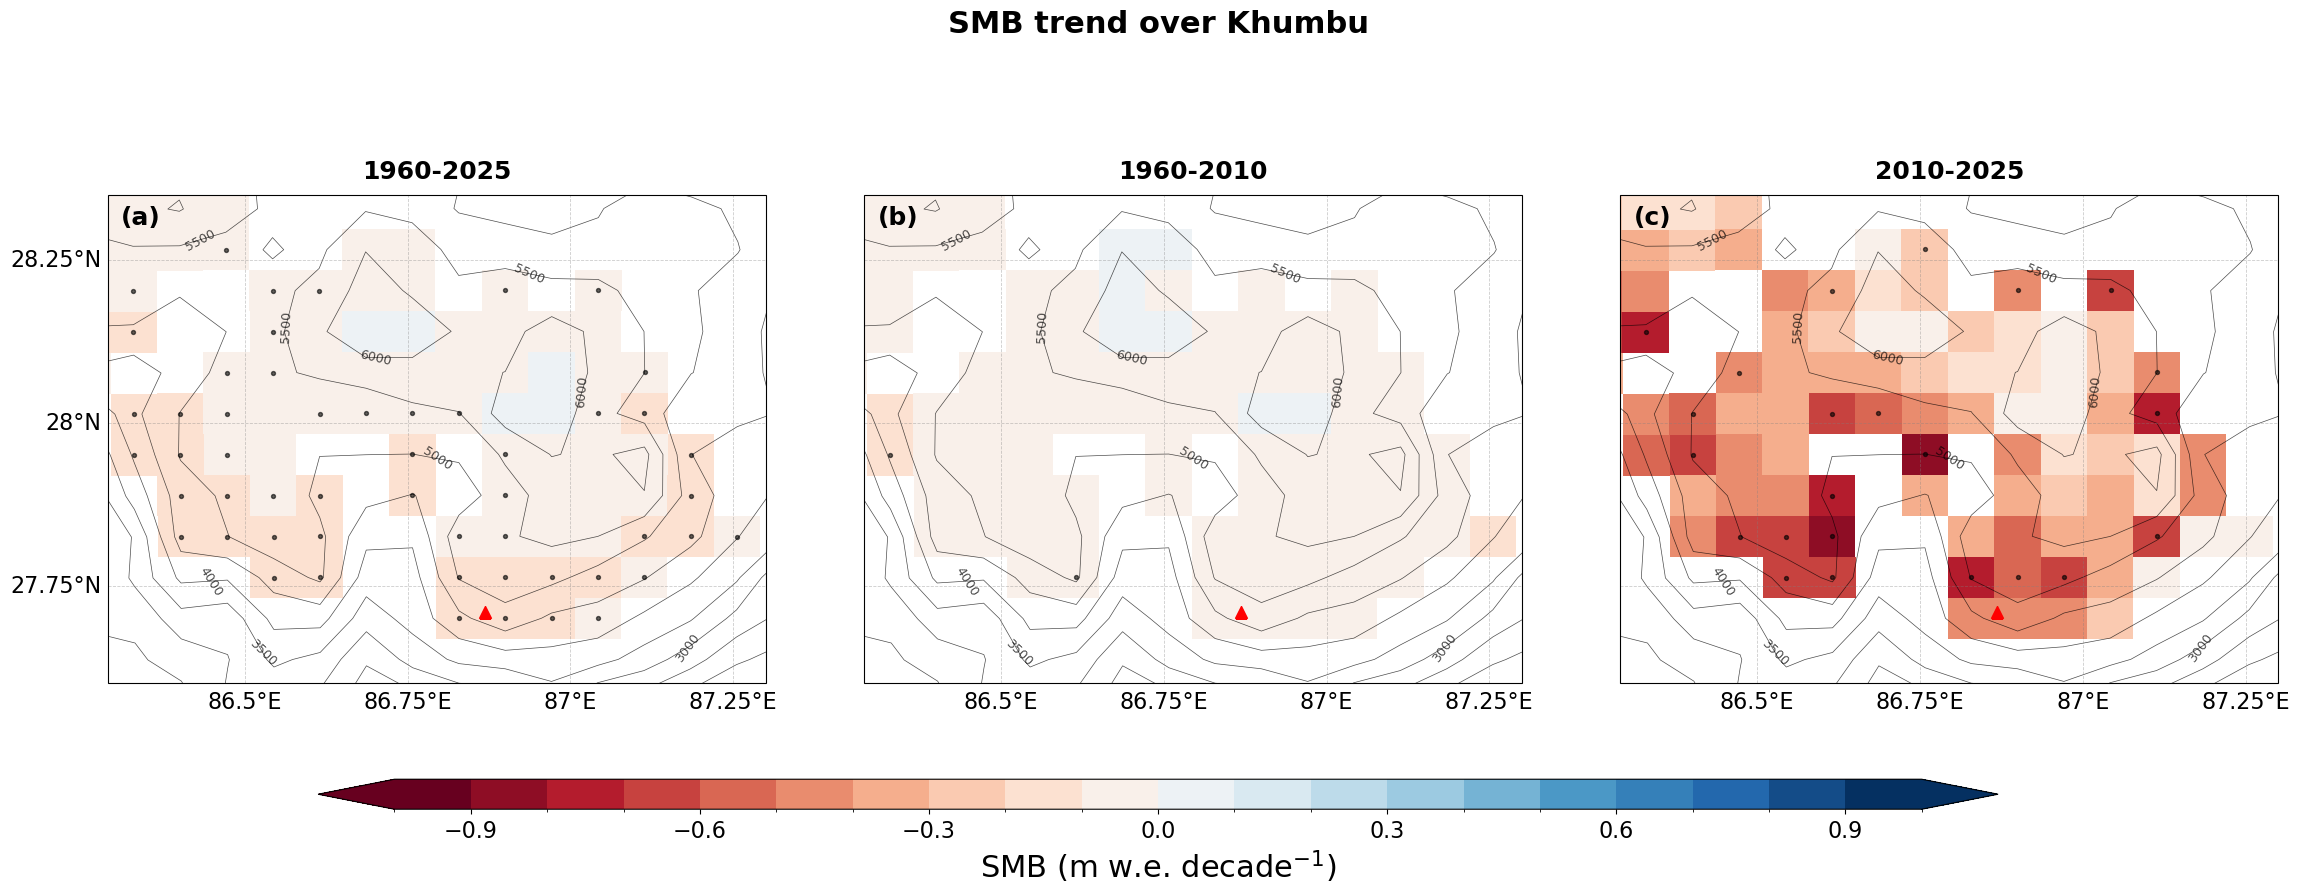

In [52]:
############### Subplot SMB trend Map (1960-2025) #######################

fig, axes = plt.subplots(1, 3, figsize=(28, 10), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
periods = [(1960, 2025), (1960, 2010), (2010, 2025)]

########## Color map ###############
vmin = -1
vmax = 1
step = 0.1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))

panel_labels = ["(a)", "(b)", "(c)"]

#############################################################
############### Boucles pour les périodes ###################
for ax, (start, end), label in zip(axes, periods, panel_labels):

    ds = SMB.sel(time=slice(f"{start}-01", f"{end}-12")) # Selection de période

    annual_values = ds.groupby("time.year").sum(dim='time', skipna=True)
    annual_values = annual_values.load()
    years = annual_values["year"].values
    slope, intercept, rvalue, pvalue, stderr = trend_vect(years, annual_values, dim="year")
    annual_trend = slope * 10 / 1000
    annual_trend_masked = annual_trend.where(annual_trend != 0) # Permet de mettre en blanc les valeurs strictement égales à 0


    
    ############### Plot ###################
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

    ########### Topography lines values #############
    manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
    ax.clabel(SH, inline=False, fontsize=9, fmt='%d', manual=manual_locations)

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# SMB moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, annual_trend_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

    lon2d = ds_lon.values
    lat2d = ds_lat.values

    sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
    step = 1
    mask = sig.values

    ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.6) # Affiche les valeurs significatives des tendances



    
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}
    gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
    gl.ylocator = mticker.MaxNLocator(3)

    ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
    ax.set_title(f"{start}-{end}",fontsize=18,weight="bold", pad=12)


    ax.text(0.02, 0.98, label, transform=ax.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')
#######################################################################
#######################################################################    

fig.suptitle("SMB trend over Khumbu", fontsize=22, weight="bold", y=0.93) 

cbar_ax = fig.add_axes([0.2, 0.13, 0.6, 0.03])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("SMB (m w.e. decade$^{-1}$)", fontsize=22)

cbar.ax.tick_params(labelsize=16)

plt.subplots_adjust(wspace=0.15,top=0.88,bottom=0.12)

plt.savefig("Trend_SMB_sub.png", dpi=400, bbox_inches="tight")

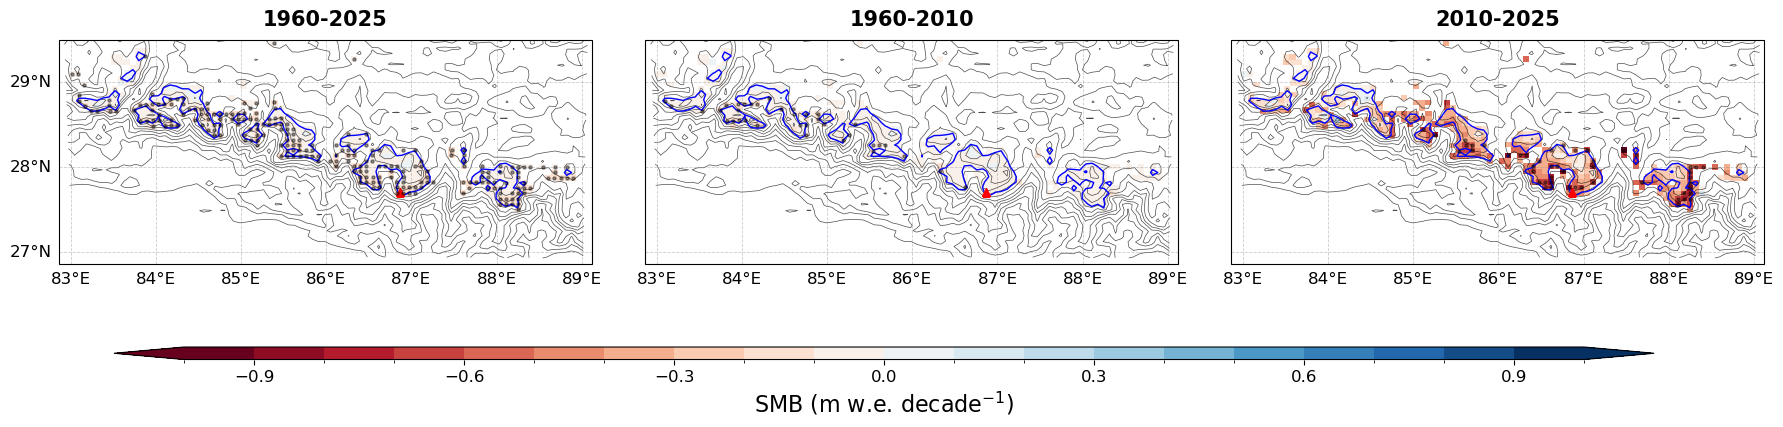

In [20]:
############### Subplot SMB trend Map (1960-2025) #######################

fig, axes = plt.subplots(1, 3, figsize=(22, 5), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
periods = [(1960, 2025), (1960, 2010), (2010, 2025)]

########## Color map ###############
vmin = -1
vmax = 1
step = 0.1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


#############################################################
############### Boucles pour les périodes ###################
for ax, (start, end) in zip(axes, periods):

    ds = SMB.sel(time=slice(f"{start}-01", f"{end}-12")) # Selection de période

    annual_values = ds.groupby("time.year").sum(dim='time', skipna=True)
    annual_values = annual_values.load()
    years = annual_values["year"].values
    slope, intercept, rvalue, pvalue, stderr = trend_vect(years, annual_values, dim="year")
    annual_trend = slope * 10 / 1000
    annual_trend_masked = annual_trend.where(annual_trend != 0) # Permet de mettre en blanc les valeurs strictement égales à 0


    
    ############### Plot ###################
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

    ######## Countour glaciers #########
    ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=6, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# SMB moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, annual_trend_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

    lon2d = ds_lon.values
    lat2d = ds_lat.values

    sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
    step = 1
    mask = sig.values

    ax.scatter(lon2d[mask], lat2d[mask], color='black', s=5, transform=ccrs.PlateCarree(), zorder=5, alpha=0.4) # Affiche les valeurs significatives des tendances



    
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}
    gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
    gl.ylocator = mticker.MaxNLocator(3)

    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())

    ax.set_title(f"{start}-{end}",fontsize=15,weight="bold", pad=10)

#######################################################################
#######################################################################    

cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.025])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("SMB (m w.e. decade$^{-1}$)", fontsize=16)

cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(wspace=0.1) # Espacement subplots

plt.savefig("Trend_SMB_sub.png")
